# Análisis FBG: 3 sensores fibra de PEEK-6 para test de calidad

## 1️⃣ Importar Librerías

In [1]:
# Reiniciar kernel si hay problemas con imports
import sys
print(f"Python ejecutable: {sys.executable}")
print(f"Python versión: {sys.version}")

# Verificar que scipy está disponible
try:
    import scipy
    print("✅ scipy disponible")
except ImportError:
    print("❌ scipy no encontrado - instalando...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    print("✅ scipy instalado - reinicia el kernel")

Python ejecutable: /usr/bin/python3.11
Python versión: 3.11.13 (main, Jan 16 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-11)]
✅ scipy disponible


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy import stats
import uproot

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2️⃣ Cargar Datos del Archivo ROOT

In [3]:
# 🔧 CONFIGURA AQUÍ LA RUTA DE TU ARCHIVO
# Archivo de datos para la fibra de poliamida POLY-1
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260302.root"

print(f"📂 Cargando archivo ROOT para fibra POLY-1: {filepath}")

# Verificar que el archivo existe
import os
if not os.path.exists(filepath):
    print(f"❌ ERROR: Archivo no encontrado: {filepath}")
    raise FileNotFoundError(f"El archivo {filepath} no existe")

# Verificar tamaño del archivo
file_size = os.path.getsize(filepath)
print(f"📊 Tamaño del archivo: {file_size / (1024**2):.2f} MB")

if file_size < 1000:  # Menos de 1 KB es sospechoso
    print(f"⚠️  ADVERTENCIA: El archivo parece muy pequeño ({file_size} bytes)")
    print(f"   Puede estar corrupto o vacío")

# Cargar datos del archivo ROOT
try:
    print("\n🔄 Abriendo archivo ROOT...")
    file = uproot.open(filepath)
    print("✅ Archivo ROOT abierto correctamente")
    
    # Mostrar estructura del archivo
    print("\n📋 Estructura del archivo ROOT:")
    print(f"   Keys disponibles: {file.keys()}")
    
    # Cargar TTrees por nombre correcto
    print(f"\n🌳 Cargando TTrees individuales...")
    
    # Cargar cada TTree por separado (usa la última versión automáticamente)
    tree_peak = file["peak"]
    # Cargar espectros si existen
    spectrum_keys = [k for k in file.keys() if k.startswith('spectrum')]
    if spectrum_keys:
        tree_spectrum = file["spectrum"]
        print(f"   ✅ TTree 'spectrum' cargado: {tree_spectrum.num_entries} entradas")
        print(f"   Branches en 'spectrum': {tree_spectrum.keys()}")
    else:
        tree_spectrum = None
        print(f"   ⚠️  TTree 'spectrum' no encontrado en el archivo ROOT")
    
    print(f"   ✅ TTree 'peak' cargado: {tree_peak.num_entries} entradas")
    
    print(f"\n   Branches en 'peak': {tree_peak.keys()}")
    
    # Extraer datos en arrays de NumPy
    print("\n📦 Extrayendo datos a arrays NumPy...")
    data_peak = tree_peak.arrays(library="np")
    if tree_spectrum is not None:
        data_spectrum = tree_spectrum.arrays(library="np")
        print(f"   ✅ Datos de espectros extraídos: {len(data_spectrum)} branches")
        print(f"   Keys espectros: {list(data_spectrum.keys())}")
    else:
        data_spectrum = None
    
    # Combinar en un solo diccionario para compatibilidad con el resto del código
    data = {}
    
    # Agregar datos de wavelength (picos)
    for key in data_peak.keys():
        data[key] = data_peak[key]
    
    # Agregar datos de espectros si existen
    if data_spectrum is not None:
        # Si existen branches 'wav' y 't', agregarlos como 'spectrum_wav' y 'spectrum_t'
        if 'wav' in data_spectrum and 't' in data_spectrum:
            data['spectrum_wav'] = data_spectrum['wav']
            data['spectrum_t'] = data_spectrum['t']
        # Agregar todos los branches de espectro con prefijo 'spectrum_'
        for key in data_spectrum.keys():
            data[f"spectrum_{key}"] = data_spectrum[key]
    
    print(f"\n✅ Datos extraídos y combinados correctamente")
    print(f"   Total de branches: {len(data.keys())}")
    print(f"   Keys disponibles: {list(data.keys())}")

except FileNotFoundError:
    print(f"\n❌ ERROR CRÍTICO: No se puede acceder al archivo")
    print(f"   Ruta: {filepath}")
    print(f"   Verifica que:")
    print(f"   1. Estás ejecutando desde lxplus")
    print(f"   2. El archivo existe en /eos/")
    print(f"   3. Tienes permisos de lectura")
    raise
except Exception as e:
    print(f"\n❌ ERROR al cargar datos: {e}")
    print(f"   Tipo de error: {type(e).__name__}")
    import traceback
    traceback.print_exc()
    raise

# Verificar que tenemos los datos esperados
print(f"\n🔍 Verificando datos cargados...")
print(f"   Keys totales: {len(data.keys())}")
print(f"   Keys disponibles: {list(data.keys())}")


📂 Cargando archivo ROOT para fibra POLY-1: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260302.root
📊 Tamaño del archivo: 124.12 MB

🔄 Abriendo archivo ROOT...
✅ Archivo ROOT abierto correctamente

📋 Estructura del archivo ROOT:
   Keys disponibles: ['peak;3', 'spectrum;6']

🌳 Cargando TTrees individuales...
   ✅ TTree 'spectrum' cargado: 915 entradas
   Branches en 'spectrum': ['t', 'wav']
   ✅ TTree 'peak' cargado: 228750 entradas

   Branches en 'peak': ['t', 'wav', 'sweep', 'ch', 'pos']

📦 Extrayendo datos a arrays NumPy...
   ✅ Datos de espectros extraídos: 2 branches
   Keys espectros: ['t', 'wav']

✅ Datos extraídos y combinados correctamente
   Total de branches: 7
   Keys disponibles: ['t', 'wav', 'sweep', 'ch', 'pos', 'spectrum_wav', 'spectrum_t']

🔍 Verificando datos cargados...
   Keys totales: 7
   Keys disponibles: ['t', 'wav', 'sweep', 'ch', 'pos', 'spectrum_wav', 'spectrum_t']


## 3️⃣ Filtrar Rango Temporal

In [4]:
# 📊 Número de sensores FBG a analizar
num_sensores = 3  # Este experimento tiene 3 sensores FBG

# Extraer wavelengths y calcular media de polarizaciones
# Estructura de wav: (n_medidas, 2_polarizaciones, n_sensores)
wav_raw = data_peak["wav"]

# wav_raw ya tiene forma (n_medidas, 2, num_sensores)
# Necesitamos reordenarlo a (n_medidas, num_sensores, 2) para media
wav_reshaped = np.transpose(wav_raw, (0, 2, 1))  # (n_medidas, num_sensores, 2_pol)

# Calcular media entre polarizaciones para cada sensor
wav_mean = np.mean(wav_reshaped, axis=2)  # (n_medidas, num_sensores)

# Buscar el branch correcto para los tiempos de wavelength
if 't' in data_peak:
    time_wavelength_raw = data_peak['t']
elif 'timestamps' in data:
    time_wavelength_raw = data['timestamps']
else:
    raise NameError("No se encontró el branch de tiempo para wavelength (ni 't' ni 'timestamps')")

# Verificar si times es 2D o 1D
if len(time_wavelength_raw.shape) == 2:
    # Si es 2D, tomar la primera columna (pol P)
    times_all = time_wavelength_raw[:, 0]
else:
    times_all = time_wavelength_raw

print(f"\n📊 Resumen de datos cargados:")
print(f"   Wavelength (media pol): {wav_mean.shape} = {wav_mean.shape[0]:,} medidas × {num_sensores} sensores")
print(f"   Timestamps wavelength: {len(times_all):,}")
print(f"   Timestamps dtype: {times_all.dtype}")

# ============================================================================
# ⬅️ AJUSTA AQUÍ EL RANGO TEMPORAL QUE QUIERES ANALIZAR
# ============================================================================
use_full_range = False  # Cambiar a False para rango específico

if use_full_range:
    t_inicio = times_all[0]
    t_fin = times_all[-1]
else:
    fecha = datetime.date(2026, 3, 2)
    t_inicio_dt = datetime.datetime.combine(fecha, datetime.time(15, 0))
    t_fin_dt = datetime.datetime.combine(fecha, datetime.time(15, 20))
    # Convertir a timestamp Unix si times_all es float
    if times_all.dtype in [np.float64, np.float32]:
        t_inicio = t_inicio_dt.timestamp()
        t_fin = t_fin_dt.timestamp()
        print(f"\n⚙️  Convertido a Unix timestamps: {t_inicio} - {t_fin}")
    else:
        t_inicio = t_inicio_dt
        t_fin = t_fin_dt

# Filtrar wavelength
mask_time = (times_all >= t_inicio) & (times_all <= t_fin)
times_filtered = times_all[mask_time]
wav_filtered = wav_raw[mask_time]

# Imprimir rango seleccionado con conversión segura a string
def safe_strftime(dt, fmt):
    import datetime
    if isinstance(dt, datetime.datetime):
        return dt.strftime(fmt)
    elif isinstance(dt, (int, float, np.float64, np.float32)):
        # Unix timestamp
        dt_obj = datetime.datetime.fromtimestamp(dt)
        return dt_obj.strftime(fmt)
    elif hasattr(dt, 'astype'):
        try:
            dt_obj = dt.astype('datetime64[s]').astype(datetime.datetime)
            return dt_obj.strftime(fmt)
        except Exception:
            return str(dt)
    else:
        return str(dt)

if use_full_range:
    print(f"\n✅ Rango seleccionado: COMPLETO")
else:
    print(f"\n✅ Rango seleccionado: {safe_strftime(t_inicio, '%Y-%m-%d %H:%M')} - {safe_strftime(t_fin, '%H:%M')}")
print(f"   Puntos wavelength: {len(times_filtered):,}")
if len(times_filtered) == 0:
    print(f"\n⚠️  Sin datos en el rango. Activa 'use_full_range = True' o ajusta t_inicio/t_fin.")



📊 Resumen de datos cargados:
   Wavelength (media pol): (228750, 8) = 228,750 medidas × 3 sensores
   Timestamps wavelength: 228,750
   Timestamps dtype: float64

⚙️  Convertido a Unix timestamps: 1772460000.0 - 1772461200.0

✅ Rango seleccionado: 2026-03-02 15:00 - 15:20
   Puntos wavelength: 69,563


In [5]:
# 🕐 MOSTRAR RANGO TEMPORAL COMPLETO DEL DATASET
print("\n" + "="*70)
print("  📅 RANGO TEMPORAL DEL DATASET COMPLETO")
print("="*70)

# Convertir timestamps Unix a datetime
t_first = datetime.datetime.fromtimestamp(times_all[0])
t_last = datetime.datetime.fromtimestamp(times_all[-1])
duration = t_last - t_first

print(f"\n  Primer punto:")
print(f"    Unix timestamp: {times_all[0]:.2f}")
print(f"    Fecha/hora:     {t_first.strftime('%Y-%m-%d %H:%M:%S')}")

print(f"\n  Último punto:")
print(f"    Unix timestamp: {times_all[-1]:.2f}")
print(f"    Fecha/hora:     {t_last.strftime('%Y-%m-%d %H:%M:%S')}")

print(f"\n  Duración total:")
print(f"    {duration}")
print(f"    ({duration.total_seconds()/3600:.2f} horas)")

print(f"\n  Puntos totales: {len(times_all):,}")
print(f"  Frecuencia promedio: {len(times_all)/duration.total_seconds():.2f} Hz")

print("\n" + "="*70)
print("💡 Usa estos valores para ajustar t_inicio y t_fin en la celda siguiente")
print("="*70 + "\n")



  📅 RANGO TEMPORAL DEL DATASET COMPLETO

  Primer punto:
    Unix timestamp: 1772437866.70
    Fecha/hora:     2026-03-02 08:51:06

  Último punto:
    Unix timestamp: 1772461331.49
    Fecha/hora:     2026-03-02 15:22:11

  Duración total:
    6:31:04.788398
    (6.52 horas)

  Puntos totales: 228,750
  Frecuencia promedio: 9.75 Hz

💡 Usa estos valores para ajustar t_inicio y t_fin en la celda siguiente



## 5️⃣ Procesamiento FBG: Filtrado y Media de Polarizaciones

### 5.1 Configuración de 4 Sensores FBG

In [6]:
# ✅ CONFIGURACIÓN: 3 sensores FBG (PEEK-3)
# 3 sensores × 2 polarizaciones = 6 canales
# Índices 0-based: sensor 0, 1, 2 (Python indexing)
fbg_config = []
for sensor in range(3):
    fbg_config.append({"pol": 0, "sensor": sensor, "label": f"FBG-{sensor+1}-P"})
    fbg_config.append({"pol": 1, "sensor": sensor, "label": f"FBG-{sensor+1}-S"})
print(f"✅ Configurados {len(fbg_config)} canales FBG (3 sensores × 2 polarizaciones)")
print(f"💡 Se verificará si hay datos válidos para todos los sensores en este dataset")


✅ Configurados 6 canales FBG (3 sensores × 2 polarizaciones)
💡 Se verificará si hay datos válidos para todos los sensores en este dataset


### 5.2 Filtrado Wavelength (μ±3σ)

In [7]:
def filter_wavelength_data(wav_data, timestamps, sigma_threshold=3.0, use_robust=True):
    """
    Filtra wavelength usando método μ±3σ o método robusto basado en mediana (MAD)
    
    Parameters:
    -----------
    wav_data : array
        Datos de wavelength a filtrar
    timestamps : array
        Timestamps correspondientes
    sigma_threshold : float
        Número de sigmas (o MADs) para el threshold
    use_robust : bool
        Si True, usa MAD (Median Absolute Deviation) en lugar de std
    """
    mask_positive = wav_data > 0
    wav_positive = wav_data[mask_positive]
    
    # Si no hay datos válidos, retornar estructura vacía
    if len(wav_positive) == 0:
        return {
            "timestamps": np.array([]),
            "wavelength": np.array([]),
            "mean": np.nan,
            "std": np.nan,
            "n_valid": 0
        }
    
    if use_robust:
        # Método robusto: usa MEDIANA y MAD (más resistente a outliers)
        median_wav = np.median(wav_positive)
        mad = np.median(np.abs(wav_positive - median_wav))
        # Convertir MAD a escala comparable con std (factor 1.4826)
        sigma_equiv = 1.4826 * mad
        
        threshold_min = median_wav - sigma_threshold * sigma_equiv
        threshold_max = median_wav + sigma_threshold * sigma_equiv
        
        # Filtrar usando los thresholds robustos
        mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
        
        # Calcular estadísticas finales sobre datos filtrados
        wav_filtered = wav_data[mask_filtered]
        mean_wav = np.mean(wav_filtered)
        std_wav = np.std(wav_filtered)
    else:
        # Método clásico: μ±3σ
        mean_wav = np.mean(wav_positive)
        std_wav = np.std(wav_positive)
        threshold_min = mean_wav - sigma_threshold * std_wav
        threshold_max = mean_wav + sigma_threshold * std_wav
        
        mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
    
    return {
        "timestamps": timestamps[mask_filtered],
        "wavelength": wav_data[mask_filtered],
        "mean": mean_wav,
        "std": std_wav,
        "n_valid": np.sum(mask_filtered)
    }
    
    # DIAGNÓSTICO: Verificar forma y valores de los sensores
    print(f"🔍 Forma de wav_filtered: {wav_filtered.shape}")
    print(f"   Dimensiones: (time={wav_filtered.shape[0]}, pol={wav_filtered.shape[1]}, sensor={wav_filtered.shape[2]})")
    print(f"\n🔍 Diagnóstico de valores por sensor (FBG-1 a FBG-8):")
    for sensor_idx in range(8):
        for pol_idx in range(2):
            pol_name = "P" if pol_idx == 0 else "S"
            sensor_data = wav_filtered[:, pol_idx, sensor_idx]
            n_positive = np.sum(sensor_data > 0)
            if n_positive > 0:
                min_val = np.min(sensor_data[sensor_data > 0])
                max_val = np.max(sensor_data)
                mean_val = np.mean(sensor_data[sensor_data > 0])
            else:
                min_val = max_val = mean_val = 0
            print(f"   FBG-{sensor_idx+1}-{pol_name}: {n_positive:7d} pts > 0, range=[{min_val:.2e}, {max_val:.2e}] nm, μ={mean_val:.2e} nm")

### 5.3 Calcular Media de Polarizaciones

In [8]:
# Filtrar datos wavelength para cada sensor y polarización (3 sensores × 2 pol)
# Diagnóstico de shapes y tipos
print(f"wav_raw shape: {wav_raw.shape}")
print(f"times_all shape: {times_all.shape}")
print(f"times_all[0]: {times_all[0]}")

# times_all ya es 1D (timestamps Unix)
times_wav = times_all
print(f"times_wav shape: {times_wav.shape}, dtype: {times_wav.dtype}, first: {times_wav[0]}")

# Usar los tiempos ya filtrados de la celda anterior
t_inicio_use = t_inicio
t_fin_use = t_fin
print(f"t_inicio: {t_inicio_use}, t_fin: {t_fin_use}, type: {type(t_inicio_use)}")

# Crear máscara temporal (ya se filtró en la celda anterior, pero aquí se rehace por claridad)
mask_time = (times_wav >= t_inicio_use) & (times_wav <= t_fin_use)
print(f"mask_time shape: {mask_time.shape}, sum: {np.sum(mask_time)}")

fbg_filtered_data = {}
for config in fbg_config:
    pol = config['pol']
    sensor = config['sensor']
    label = config['label']
    wav_sensor_pol = wav_raw[:, pol, sensor][mask_time]
    timestamps_sensor = times_wav[mask_time]
    filtered = filter_wavelength_data(wav_sensor_pol, timestamps_sensor, sigma_threshold=3.0, use_robust=True)
    fbg_filtered_data[label] = filtered
print(f"✅ Datos filtrados para {len(fbg_filtered_data)} canales (3 sensores × 2 pol)")


wav_raw shape: (228750, 2, 8)
times_all shape: (228750,)
times_all[0]: 1772437866.701463
times_wav shape: (228750,), dtype: float64, first: 1772437866.701463
t_inicio: 1772460000.0, t_fin: 1772461200.0, type: <class 'float'>
mask_time shape: (228750,), sum: 69563
✅ Datos filtrados para 6 canales (3 sensores × 2 pol)


In [9]:
# Calcular media P+S para cada sensor (3 sensores: 1 a 3)
fbg_mean_data = {}

for sensor_num in range(1, 4):  # Sensores 1 a 3
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    label_mean = f"FBG-{sensor_num}-Mean"
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    times_p = data_p["timestamps"]
    times_s = data_s["timestamps"]
    wav_p = data_p["wavelength"]
    wav_s = data_s["wavelength"]
    # Verificar que hay datos válidos
    if len(times_p) == 0 or len(times_s) == 0:
        print(f"⚠️ FBG-{sensor_num} no tiene datos suficientes, omitiendo...")
        continue
    # Interpolar S a tiempos de P (usar directamente los float timestamps)
    times_p_sec = np.array(times_p)
    times_s_sec = np.array(times_s)
    wav_s_interp = np.interp(times_p_sec, times_s_sec, wav_s)
    # Media
    wav_mean = (wav_p + wav_s_interp) / 2.0
    fbg_mean_data[label_mean] = {
        "timestamps": times_p,
        "wavelength": wav_mean,
        "mean": np.mean(wav_mean),
        "std": np.std(wav_mean),
        "n_valid": len(wav_mean),
        "sensor_num": sensor_num
    }

print("✅ Medias calculadas (P+S)/2 para todos los sensores")
print(f"\n{'Sensor':<15} {'Mean (nm)':<15} {'Std (nm)':<15} {'N puntos'}")
print("="*65)
for label, data in fbg_mean_data.items():
    print(f"{label:<15} {data['mean']:<15.6e} {data['std']:<15.6e} {data['n_valid']}")


✅ Medias calculadas (P+S)/2 para todos los sensores

Sensor          Mean (nm)       Std (nm)        N puntos
FBG-1-Mean      1.541381e-06    4.409007e-12    68929
FBG-2-Mean      1.544489e-06    1.473995e-12    60347
FBG-3-Mean      1.547421e-06    2.624107e-12    68512


### 5.4 Visualizar Wavelengths (Media de Polarizaciones)

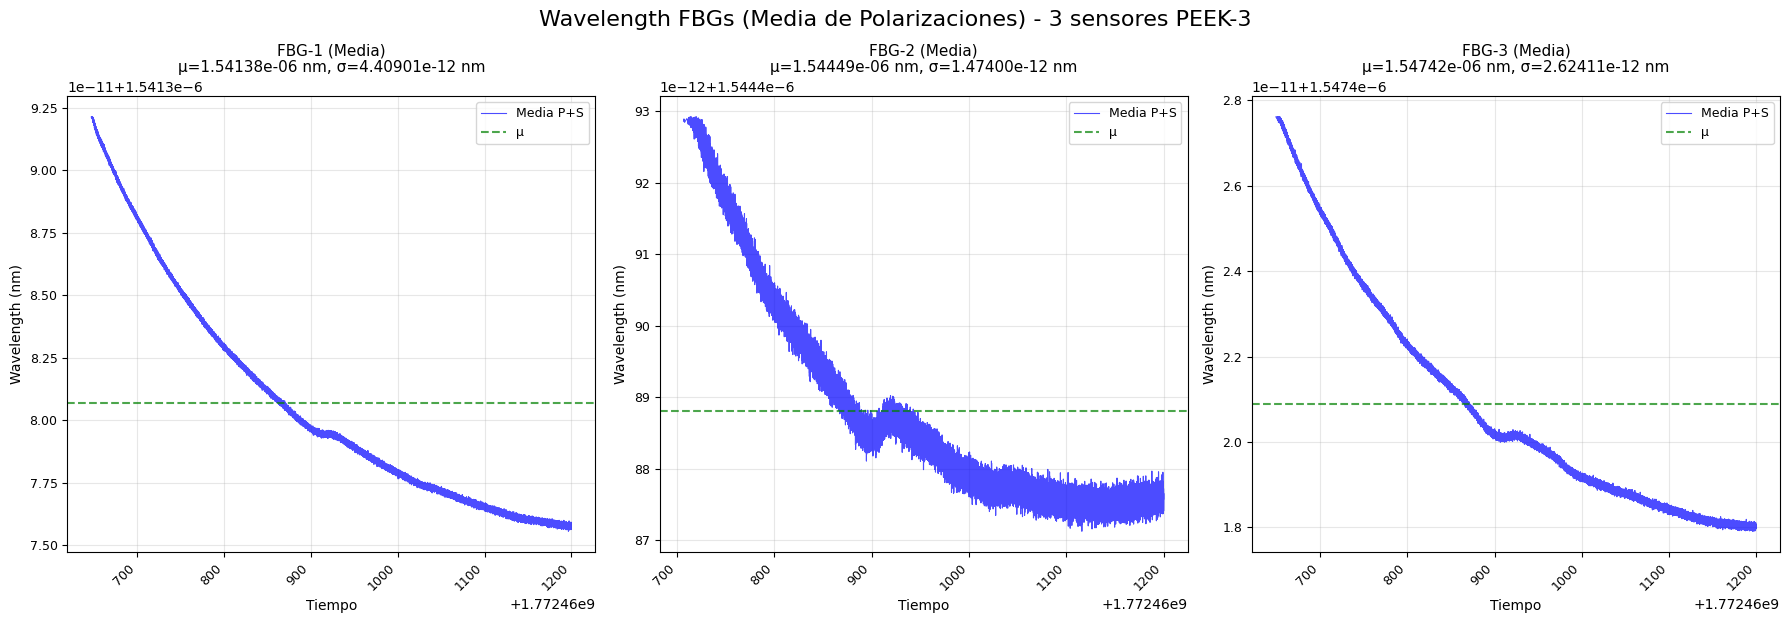

💡 No hay plateaus definidos en este análisis


In [10]:
# Visualizar Wavelengths (Media de Polarizaciones) para 3 sensores
n_sensors = len(fbg_mean_data)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
if n_sensors == 1:
    axes = [axes]

for idx, (label, data) in enumerate(fbg_mean_data.items()):
    times_fbg = data["timestamps"]
    wav_fbg = data["wavelength"]
    sensor_num = data["sensor_num"]
    axes[idx].plot(times_fbg, wav_fbg, 'b-', linewidth=0.8, alpha=0.7, label='Media P+S')
    axes[idx].axhline(data['mean'], color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='μ')
    # Añadir líneas verticales de plateaus (si están definidos)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for plateau in plateau_data:
            axes[idx].axvline(plateau["t0"], color='red', linestyle='--', linewidth=1.2, alpha=0.5)
            axes[idx].axvline(plateau["tfin"], color='blue', linestyle='--', linewidth=1.2, alpha=0.5)
    axes[idx].set_title(f"FBG-{sensor_num} (Media)\nμ={data['mean']:.5e} nm, σ={data['std']:.5e} nm", fontsize=11)
    axes[idx].set_xlabel('Tiempo', fontsize=10)
    axes[idx].set_ylabel('Wavelength (nm)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9)
    axes[idx].tick_params(labelsize=9)
    for tick_label in axes[idx].get_xticklabels():
        tick_label.set_rotation(45)
        tick_label.set_ha('right')

plt.tight_layout()
plt.suptitle(f'Wavelength FBGs (Media de Polarizaciones) - {n_sensors} sensores PEEK-3', fontsize=16, y=1.03)
plt.show()

if 'plateau_data' in globals() and len(plateau_data) > 0:
    print(f"🔴🔵 Plateaus marcados con líneas verticales (rojo=inicio, azul=fin)")
else:
    print(f"💡 No hay plateaus definidos en este análisis")


spectrum_wav shape: (915, 2, 3, 39200)


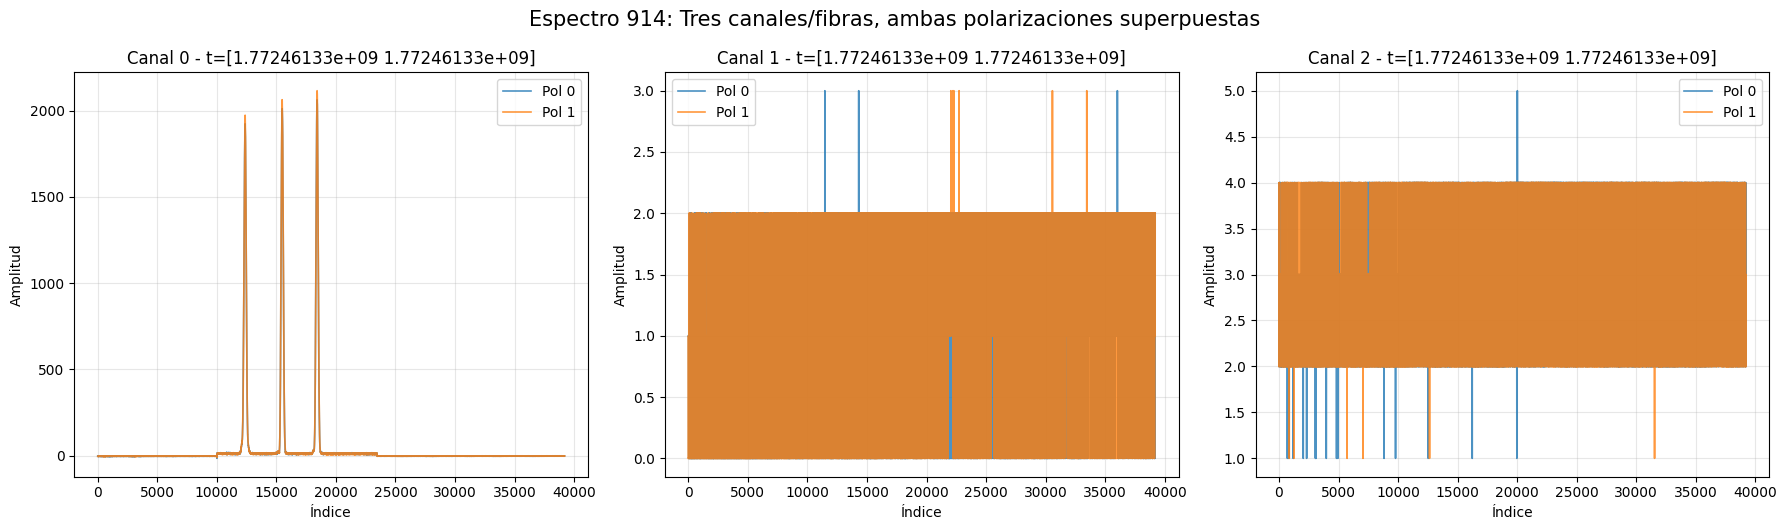

In [11]:
# Plotear espectro completo para canales 0, 1 y 2, ambas polarizaciones superpuestas
import uproot
import matplotlib.pyplot as plt
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260302.root"
file = uproot.open(filepath)
tree_spectrum = file["spectrum"]
data_spectrum = tree_spectrum.arrays(library="np")
spectrum_wav = data_spectrum['wav']  # shape: (n_espectros, n_pol, n_chan, n_puntos)
spectrum_t = data_spectrum['t']      # shape: (n_espectros,)
shape = spectrum_wav.shape
print(f"spectrum_wav shape: {shape}")
if len(shape) == 4:
    n_espectros, n_pol, n_chan, n_puntos = shape
    idx_espectro = n_espectros - 1  # Último espectro
    canales_a_mostrar = [0, 1, 2]
    pol_labels = ['Pol 0', 'Pol 1']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, idx_chan in enumerate(canales_a_mostrar):
        ax = axes[i]
        for idx_pol in range(n_pol):
            wav = spectrum_wav[idx_espectro, idx_pol, idx_chan, :]
            ax.plot(wav, label=pol_labels[idx_pol], linewidth=1.2, alpha=0.8)
        t = spectrum_t[idx_espectro]
        ax.set_title(f'Canal {idx_chan} - t={t}')
        ax.set_xlabel('Índice')
        ax.set_ylabel('Amplitud')
        ax.grid(True, alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.suptitle(f'Espectro {idx_espectro}: Tres canales/fibras, ambas polarizaciones superpuestas', fontsize=15, y=1.05)
    plt.show()
else:
    print("Estructura inesperada en spectrum_wav. Esperado 4D (espectro, pol, canal, puntos).")


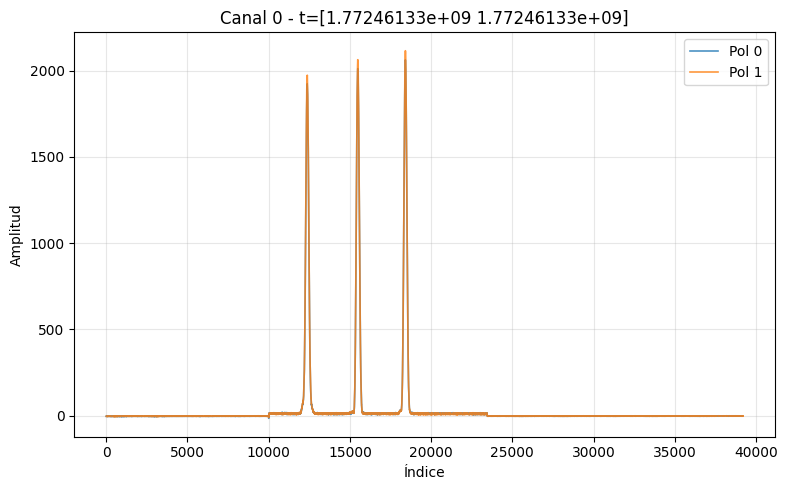

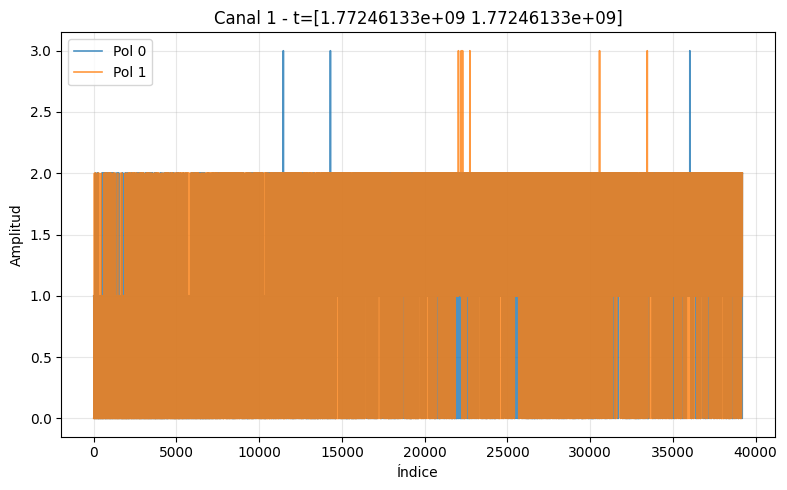

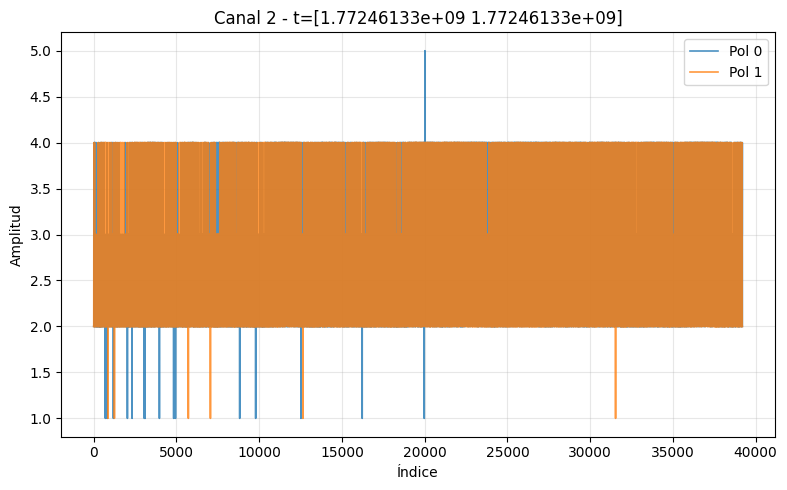

In [12]:
# Espectro canal 0 (ambas polarizaciones)
import uproot
import matplotlib.pyplot as plt
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260302.root"
file = uproot.open(filepath)
tree_spectrum = file["spectrum"]
data_spectrum = tree_spectrum.arrays(library="np")
spectrum_wav = data_spectrum['wav']
spectrum_t = data_spectrum['t']
shape = spectrum_wav.shape
idx_espectro = shape[0] - 1  # Último espectro
idx_chan = 0
n_pol = shape[1]
pol_labels = ['Pol 0', 'Pol 1']
plt.figure(figsize=(8, 5))
for idx_pol in range(n_pol):
    wav = spectrum_wav[idx_espectro, idx_pol, idx_chan, :]
    plt.plot(wav, label=pol_labels[idx_pol], linewidth=1.2, alpha=0.8)
t = spectrum_t[idx_espectro]
plt.title(f'Canal {idx_chan} - t={t}')
plt.xlabel('Índice')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
# Espectro canal 1 (ambas polarizaciones)
idx_chan = 1
plt.figure(figsize=(8, 5))
for idx_pol in range(n_pol):
    wav = spectrum_wav[idx_espectro, idx_pol, idx_chan, :]
    plt.plot(wav, label=pol_labels[idx_pol], linewidth=1.2, alpha=0.8)
t = spectrum_t[idx_espectro]
plt.title(f'Canal {idx_chan} - t={t}')
plt.xlabel('Índice')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
# Espectro canal 2 (ambas polarizaciones)
idx_chan = 2
plt.figure(figsize=(8, 5))
for idx_pol in range(n_pol):
    wav = spectrum_wav[idx_espectro, idx_pol, idx_chan, :]
    plt.plot(wav, label=pol_labels[idx_pol], linewidth=1.2, alpha=0.8)
t = spectrum_t[idx_espectro]
plt.title(f'Canal {idx_chan} - t={t}')
plt.xlabel('Índice')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


✅ spectrum_wav shape : (915, 2, 3, 39200)
   λ-axis             : 1529.0–1568.2 nm  (39200 pts,  Δλ = 1.000 pm/pt)

🔍 Peaks detected:
   Pol P: ['1541.3693 nm', '1544.4854 nm', '1547.4145 nm']
   Pol S: ['1541.3773 nm', '1544.4844 nm', '1547.4185 nm']

════════════════════════════════════════════════════════════════
  PEEK-3  —  Peak Wavelengths   (ch 0, spectrum #914)
════════════════════════════════════════════════════════════════
  Sensor           λ_P (nm)       λ_S (nm)     λ_mean (nm)
  ----------------------------------------------------------
  FBG-1          1541.36932     1541.37732      1541.37332
  FBG-2          1544.48540     1544.48440      1544.48490
  FBG-3          1547.41447     1547.41847      1547.41647
════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────
  QC-1  Sensor Spacing Uniformity   (pass if |Δλ_measured - 3 nm| < 0.050 nm)
─────────────────────────────────────────────────────────

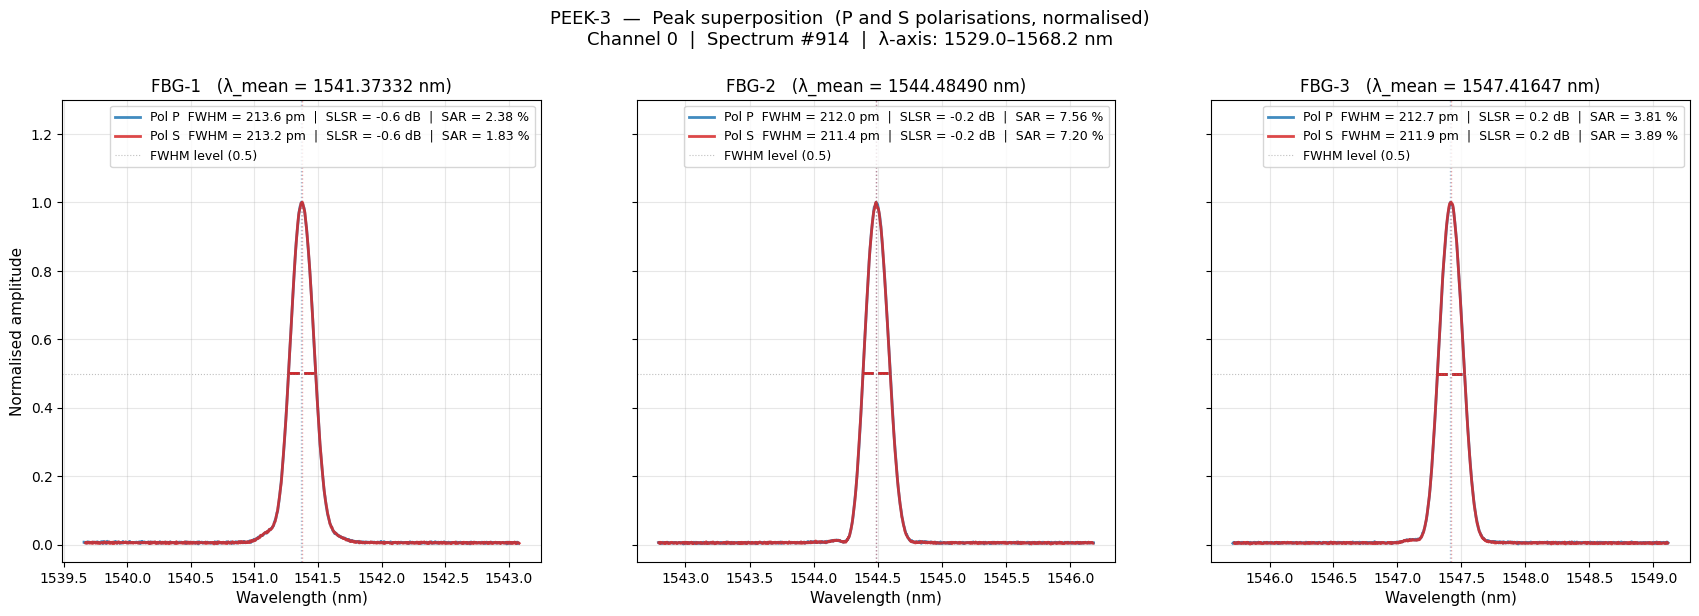


══════════════════════════════════════════════════════════════════════
  🪞 MIRROR SYMMETRY ANALYSIS
══════════════════════════════════════════════════════════════════════


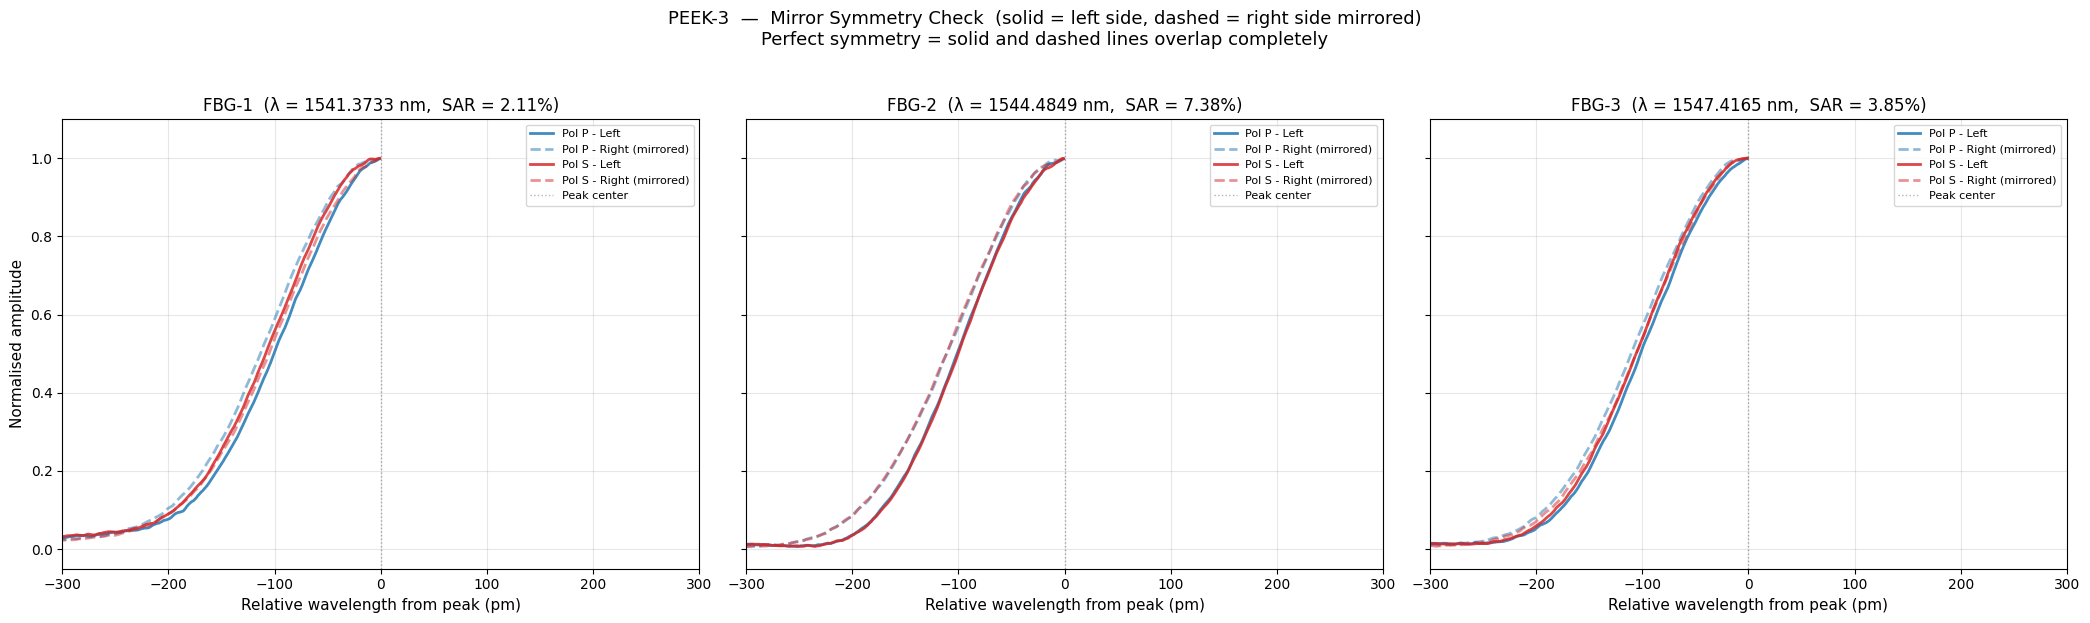


💡 How to read the mirror plot:
   • Solid lines:  Left side of peak
   • Dashed lines: Right side of peak (mirrored to overlay on left)
   • Perfect overlap → symmetric peak (SAR ≈ 0%)
   • Visible gap → asymmetric peak (higher SAR)
   • Target: SAR between 1.0% and 3.0%


In [15]:

# ══════════════════════════════════════════════════════════════════════════════
# PEEK-3  —  Quality Analysis
#   · Channel 0, 3 FBG sensors, single spectrum
#   · Peak wavelength table  (P / S / mean)
#   · QC-1  Sensor spacing uniformity
#   · QC-2  FWHM < 100 pm
#   · QC-3  SLSR > 20 dB
#   · QC-4  Spectral Asymmetry Ratio  1–3 %
#   · Plot: both polarisations superposed, normalised, per sensor
# ══════════════════════════════════════════════════════════════════════════════
from scipy.signal import find_peaks, peak_widths
import uproot, numpy as np, matplotlib.pyplot as plt

# ──────────────────────────────────────────────────────────────────────────────
# Configuration
# ──────────────────────────────────────────────────────────────────────────────
FILEPATH       = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260302.root"
CHANNEL        = 0           # PEEK-3 fibre on channel 0
N_SENSORS      = 3
LAM_START      = 1529.0      # nm  (from spectrumtest.py)
LAM_END        = 1568.2      # nm
N_POINTS       = 39200       # ≈ 1 pm/pt resolution
FWHM_THRESH_PM = 100.0       # pm   — FWHM pass threshold
SLSR_THRESH_DB =  20.0       # dB   — SLSR pass threshold
ASYM_MIN_PCT   =   1.0       # %    — lower bound of acceptable SAR
ASYM_MAX_PCT   =   3.0       # %    — upper bound of acceptable SAR
POL_LABELS     = {0: "P", 1: "S"}
COLORS_POL     = {0: "tab:blue", 1: "tab:red"}

# ──────────────────────────────────────────────────────────────────────────────
# Load spectrum
# ──────────────────────────────────────────────────────────────────────────────
_f           = uproot.open(FILEPATH)
_sd          = _f["spectrum"].arrays(library="np")
spectrum_wav = _sd["wav"]                               # (n_spec, n_pol, n_chan, n_pts)

IDX_SPEC = spectrum_wav.shape[0] - 1  # Último espectro
lam     = np.linspace(LAM_START, LAM_END, N_POINTS)     # nm
dlam_pm = (LAM_END - LAM_START) / (N_POINTS - 1) * 1e3  # pm / point

print(f"✅ spectrum_wav shape : {spectrum_wav.shape}")
print(f"   λ-axis             : {LAM_START}–{LAM_END} nm  "
      f"({N_POINTS} pts,  Δλ = {dlam_pm:.3f} pm/pt)")

# Extract channel 0 for both polarisations
# ──────────────────────────────────────────────────────────────────────────────
signals = {
    0: spectrum_wav[IDX_SPEC, 0, CHANNEL, :],   # P polarisation
    1: spectrum_wav[IDX_SPEC, 1, CHANNEL, :],   # S polarisation
}

# Helper: find N most-prominent peaks, sorted by wavelength (ascending)
# ──────────────────────────────────────────────────────────────────────────────
def find_n_peaks(signal, n=N_SENSORS, min_dist_nm=2.0,
                 min_prom_frac=0.10, min_h_frac=0.05):
    min_dist_pts = max(int(min_dist_nm / (dlam_pm * 1e-3)), 10)
    sig_max = np.max(signal)
    pks, props = find_peaks(
        signal,
        height=sig_max * min_h_frac,
        prominence=sig_max * min_prom_frac,
        distance=min_dist_pts,
    )
    if len(pks) == 0:
        return []
    if len(pks) <= n:
        return sorted(pks.tolist())
    proms   = props.get("prominences", np.ones(len(pks)))
    top_idx = np.argsort(proms)[::-1][:n]
    return sorted(pks[top_idx].tolist())

peaks_found = {pol: find_n_peaks(signals[pol]) for pol in range(2)}
print(f"\n🔍 Peaks detected:")
for pol, pname in POL_LABELS.items():
    lams_str = [f"{lam[p]:.4f} nm" for p in peaks_found[pol]]
    print(f"   Pol {pname}: {lams_str}")

# Helper: SLSR — Side-Lobe Suppression Ratio
# ──────────────────────────────────────────────────────────────────────────────
def compute_slsr(signal, peak_idx, guard_nm=2.0):
    """20·log10(main_peak / max_sidelobe)  [dB].
    Sidelobe region = entire spectrum minus ±guard_nm around the main peak."""
    guard_pts = max(int(guard_nm / (dlam_pm * 1e-3)), 1)
    mask = np.ones(len(signal), dtype=bool)
    mask[max(0, peak_idx - guard_pts):peak_idx + guard_pts + 1] = False
    if not mask.any():
        return np.inf
    sl_max = np.max(signal[mask])
    if sl_max <= 0:
        return np.inf
    return 20.0 * np.log10(signal[peak_idx] / sl_max)

# ──────────────────────────────────────────────────────────────────────────────
# Helper: Spectral Asymmetry Ratio (50-10% method)
#   A_{50-10} = |W_{L,50-10} - W_{R,50-10}| / (W_{L,50-10} + W_{R,50-10}) × 100%
#   where:
#     W_{L,50-10} = λ_{L,10} - λ_{L,50}  (left side width between 10% and 50%)
#     W_{R,50-10} = λ_{R,50} - λ_{R,10}  (right side width between 10% and 50%)
# ──────────────────────────────────────────────────────────────────────────────
def compute_asymmetry_50_10(signal, peak_idx):
    """Calculate SAR using 50-10% width method (proper definition).
    
    Returns SAR as percentage: A = |W_L - W_R| / (W_L + W_R) × 100%
    where W_L = width between 10% and 50% levels on left side
          W_R = width between 50% and 10% levels on right side
    """
    try:
        # Get positions at 50% level (FWHM)
        widths_50, heights_50, left_ips_50, right_ips_50 = peak_widths(
            signal, [peak_idx], rel_height=0.5
        )
        
        # Get positions at 10% level (rel_height=0.9 means 90% down from peak = 10% up from baseline)
        widths_10, heights_10, left_ips_10, right_ips_10 = peak_widths(
            signal, [peak_idx], rel_height=0.9
        )
        
        if len(widths_50) == 0 or len(widths_10) == 0:
            return np.nan
        
        # Extract interpolated positions (these are array indices, can be float)
        # Peak is at position peak_idx
        # Left side: positions increase from left_ip to peak_idx
        # Right side: positions increase from peak_idx to right_ip
        
        pos_L_50 = left_ips_50[0]   # Position at 50% on left side
        pos_R_50 = right_ips_50[0]  # Position at 50% on right side  
        pos_L_10 = left_ips_10[0]   # Position at 10% on left side
        pos_R_10 = right_ips_10[0]  # Position at 10% on right side
        
        # Calculate widths between 50% and 10% levels on each side (in array indices)
        # Left side: from 10% position to 50% position (moving toward peak)
        W_L_50_10 = abs(pos_L_50 - pos_L_10)
        
        # Right side: from 50% position to 10% position (moving away from peak)
        W_R_50_10 = abs(pos_R_10 - pos_R_50)
        
        # Calculate SAR (widths are in same units, so ratio is dimensionless)
        total_width = W_L_50_10 + W_R_50_10
        if total_width <= 0:
            return np.nan
        
        sar = 100.0 * abs(W_L_50_10 - W_R_50_10) / total_width
        
        return sar
        
    except Exception as e:
        return np.nan

def compute_asymmetry_multilevel(signal, peak_idx, levels=[0.1, 0.3, 0.5, 0.7]):
    """Calculate SAR at multiple amplitude levels (old method, kept for comparison)."""
    sars = []
    for rel_h in levels:
        try:
            widths, w_heights, left_ips, right_ips = peak_widths(signal, [peak_idx], rel_height=rel_h)
            if len(widths) > 0:
                dl_left  = (peak_idx - left_ips[0])  * dlam_pm   # pm
                dl_right = (right_ips[0] - peak_idx) * dlam_pm   # pm
                total = dl_left + dl_right
                if total > 0:
                    sar = 100.0 * abs(dl_right - dl_left) / total
                    sars.append(sar)
        except:
            pass
    return np.mean(sars) if len(sars) > 0 else np.nan

def compute_mirror_correlation(signal, peak_idx, window_pts=200):
    """Calculate correlation between left and right (mirrored) sides of peak."""
    # Extract window around peak
    i0 = max(0, peak_idx - window_pts)
    i1 = min(len(signal), peak_idx + window_pts + 1)
    
    # Extract left and right sides
    left_side = signal[i0:peak_idx]
    right_side = signal[peak_idx+1:i1]
    
    # Make them same length by truncating to shorter side
    min_len = min(len(left_side), len(right_side))
    if min_len < 10:  # Need minimum points for meaningful correlation
        return np.nan
    
    left_side = left_side[-min_len:]   # Take last min_len points from left
    right_side = right_side[:min_len]   # Take first min_len points from right
    
    # Mirror the right side (reverse it)
    right_mirrored = right_side[::-1]
    
    # Normalize both sides to [0, 1] for fair comparison
    left_norm = (left_side - np.min(left_side)) / (np.max(left_side) - np.min(left_side) + 1e-10)
    right_norm = (right_mirrored - np.min(right_mirrored)) / (np.max(right_mirrored) - np.min(right_mirrored) + 1e-10)
    
    # Calculate correlation coefficient
    corr = np.corrcoef(left_norm, right_norm)[0, 1]
    
    # Convert to asymmetry metric: 0% = perfect symmetry (corr=1), higher % = more asymmetric
    asymmetry_pct = 100.0 * (1.0 - corr)
    
    return asymmetry_pct

def compute_asymmetry(peak_idx, left_ip, right_ip):
    """Original FWHM-based SAR (kept for backward compatibility)."""
    dl_left  = (peak_idx - left_ip)  * dlam_pm   # pm
    dl_right = (right_ip - peak_idx) * dlam_pm   # pm
    total = dl_left + dl_right
    if total <= 0:
        return np.nan
    return 100.0 * abs(dl_right - dl_left) / total

# Compute metrics for all sensors × polarisations
# ──────────────────────────────────────────────────────────────────────────────
metrics = {}   # (sensor_1based, pol_idx) → dict or None

for pol in range(2):
    sig     = signals[pol]
    pk_list = peaks_found[pol]
    for s_idx in range(N_SENSORS):
        key = (s_idx + 1, pol)
        if s_idx >= len(pk_list):
            metrics[key] = None
            continue
        pk = pk_list[s_idx]
        widths, w_heights, left_ips, right_ips = peak_widths(sig, [pk], rel_height=0.5)
        
        # Calculate SAR using proper 50-10% method
        sar_50_10 = compute_asymmetry_50_10(sig, pk)
        
        # Keep old methods for comparison
        sar_fwhm = compute_asymmetry(pk, left_ips[0], right_ips[0])
        sar_mirror = compute_mirror_correlation(sig, pk, window_pts=300)
        
        metrics[key] = {
            "pk_idx"  : pk,
            "pk_lam"  : lam[pk],
            "fwhm_pm" : widths[0] * dlam_pm,
            "slsr_db" : compute_slsr(sig, pk),
            "asym_pct": sar_50_10,  # Use proper 50-10% method
            "asym_50_10_pct": sar_50_10,  # SAR 50-10% (correct method)
            "asym_fwhm_pct": sar_fwhm,  # FWHM-based (reference)
            "asym_mirror_pct": sar_mirror,  # Mirror correlation
            "left_ip" : left_ips[0],
            "right_ip": right_ips[0],
            "w_height": w_heights[0],
        }

# Peak Wavelength Table
# ──────────────────────────────────────────────────────────────────────────────
SEP = "═" * 64
sep = "─" * 64
print(f"\n{SEP}")
print(f"  PEEK-3  —  Peak Wavelengths   (ch {CHANNEL}, spectrum #{IDX_SPEC})")
print(SEP)
print(f"  {'Sensor':<10}  {'λ_P (nm)':>13}  {'λ_S (nm)':>13}  {'λ_mean (nm)':>14}")
print(f"  {'-'*58}")

lambda_means = []
for s in range(1, N_SENSORS + 1):
    rP = metrics.get((s, 0));  rS = metrics.get((s, 1))
    lP = f"{rP['pk_lam']:.5f}" if rP else "    N/A  "
    lS = f"{rS['pk_lam']:.5f}" if rS else "    N/A  "
    if rP and rS:
        lm = (rP["pk_lam"] + rS["pk_lam"]) / 2.0
    elif rP:
        lm = rP["pk_lam"]
    elif rS:
        lm = rS["pk_lam"]
    else:
        lm = None
    lambda_means.append(lm)
    lM = f"{lm:.5f}" if lm is not None else "    N/A  "
    print(f"  FBG-{s}       {lP:>13}  {lS:>13}  {lM:>14}")
# ──────────────────────────────────────────────────────────────────────────────
print(SEP)

# QC-1  Sensor Spacing Uniformity
# ──────────────────────────────────────────────────────────────────────────────
DESIGN_SPACING_NM = 3.0  # nm — Nominal spacing between adjacent FBG sensors
SPACING_THRESH_NM = 0.05  # nm — Tolerance for spacing deviation

print(f"\n{sep}")
print(f"  QC-1  Sensor Spacing Uniformity   (pass if |Δλ_measured - {DESIGN_SPACING_NM:.0f} nm| < {SPACING_THRESH_NM:.3f} nm)")
print(sep)

print(f"  {'Adjacent Pair':<20}  {'Δλ_design (nm)':>16}  {'Δλ_measured (nm)':>17}  {'|Δ| (nm)':>12}   Result")
print(f"  {'-'*85}")

valid_lms = [(i + 1, lm) for i, lm in enumerate(lambda_means) if lm is not None]
if len(valid_lms) >= 2:
    measured_spacings_nm = np.diff([v[1] for v in valid_lms])
    
    all_pass = True
    for i, sp_measured in enumerate(measured_spacings_nm):
        s1, s2 = valid_lms[i][0], valid_lms[i + 1][0]
        pair_label = f"FBG-{s1} → FBG-{s2}"
        
        # Use uniform design spacing for all pairs
        sp_design = DESIGN_SPACING_NM
        delta = abs(sp_measured - sp_design)
        ok = delta < SPACING_THRESH_NM
        
        print(f"  {pair_label:<20}  {sp_design:>16.3f}  {sp_measured:>17.5f}  {delta:>12.5f}   "
              f"{'✅ PASS' if ok else '❌ FAIL'}")
        
        if not ok:
            all_pass = False
    
    print(f"\n  Overall QC-1: {'✅ ALL PASS' if all_pass else '❌ SOME FAIL'}")
    print(f"  💡 Design: All adjacent sensors should be separated by {DESIGN_SPACING_NM:.0f} nm (±{SPACING_THRESH_NM*1000:.0f} pm)")
else:
    print("  ⚠️  Not enough valid peaks to compute spacing.")

# QC-2  FWHM < 100 pm
# ──────────────────────────────────────────────────────────────────────────────
print(f"\n{sep}")
print(f"  QC-2  FWHM   (pass if < {FWHM_THRESH_PM:.0f} pm)")
print(sep)
print(f"  {'Sensor':<10} {'Pol':<4}  {'FWHM (pm)':>13}   Result")
print(f"  {'-'*50}")
for s in range(1, N_SENSORS + 1):
    for pol, pname in POL_LABELS.items():
        r = metrics.get((s, pol))
        if r is None:
            print(f"  FBG-{s}      {pname:<4}  {'N/A':>13}")
            continue
        ok = r["fwhm_pm"] < FWHM_THRESH_PM
        print(f"  FBG-{s}      {pname:<4}  {r['fwhm_pm']:>13.1f}   "
              f"{'✅ PASS' if ok else '❌ FAIL'}")

# QC-3  SLSR > 20 dB
# ──────────────────────────────────────────────────────────────────────────────
print(f"\n{sep}")
print(f"  QC-3  SLSR   (pass if > {SLSR_THRESH_DB:.0f} dB)")
print(sep)
print(f"  {'Sensor':<10} {'Pol':<4}  {'SLSR (dB)':>13}   Result")
print(f"  {'-'*50}")
for s in range(1, N_SENSORS + 1):
    for pol, pname in POL_LABELS.items():
        r = metrics.get((s, pol))
        if r is None:
            print(f"  FBG-{s}      {pname:<4}  {'N/A':>13}")
            continue
        ok = r["slsr_db"] > SLSR_THRESH_DB
        print(f"  FBG-{s}      {pname:<4}  {r['slsr_db']:>13.1f}   "
              f"{'✅ PASS' if ok else '❌ FAIL'}")

# QC-4  Spectral Asymmetry Ratio  1–3 %
# ──────────────────────────────────────────────────────────────────────────────
print(f"\n{sep}")
print(f"  QC-4  Spectral Asymmetry Ratio (50-10% method)   (pass if {ASYM_MIN_PCT}–{ASYM_MAX_PCT} %)")
print(sep)
print(f"  {'Sensor':<10} {'Pol':<4}  {'SAR_50-10':>11}  {'SAR_FWHM':>10}  {'SAR_Mirror':>12}   Result")
print(f"  {'-'*75}")

sar_summary = {}  # Store for overall analysis
for s in range(1, N_SENSORS + 1):
    for pol, pname in POL_LABELS.items():
        r = metrics.get((s, pol))
        if r is None:
            print(f"  FBG-{s}      {pname:<4}  {'N/A':>11}  {'N/A':>10}  {'N/A':>12}")
            continue
        
        sar_50_10 = r["asym_50_10_pct"]  # Correct 50-10% method
        sar_fwhm = r["asym_fwhm_pct"]    # FWHM reference
        sar_mirror = r["asym_mirror_pct"] # Mirror correlation
        
        # Store for summary
        key = (s, pol)
        sar_summary[key] = {
            "50_10": sar_50_10,
            "fwhm": sar_fwhm,
            "mirror": sar_mirror,
        }
        
        # Determine pass/fail based on 50-10% method (correct definition)
        if np.isnan(sar_50_10):
            flag = "⚠️  N/A"
        elif ASYM_MIN_PCT <= sar_50_10 <= ASYM_MAX_PCT:
            flag = "✅ PASS"
        else:
            flag = f"❌ FAIL  ({'too symmetric' if sar_50_10 < ASYM_MIN_PCT else 'too asymmetric'})"
        
        print(f"  FBG-{s}      {pname:<4}  {sar_50_10:>10.2f}%  {sar_fwhm:>9.2f}%  {sar_mirror:>11.2f}%   {flag}")

# Print interpretation guide
print(f"\n  💡 SAR Metrics Explained:")
print(f"     • SAR_50-10:  Spectral Asymmetry Ratio using 50%-10% width method (STANDARD)")
print(f"                   A = |W_L - W_R| / (W_L + W_R) × 100%")
print(f"                   where W_L = λ_L,10% - λ_L,50%  and  W_R = λ_R,50% - λ_R,10%")
print(f"     • SAR_FWHM:   Reference calculation using FWHM only")
print(f"     • SAR_Mirror: Shape correlation (mirror overlay method)")
print(f"     → Pass/Fail based on SAR_50-10 (correct definition)")

# QC-5  Design Wavelength Deviation  < 0.05 nm
# ──────────────────────────────────────────────────────────────────────────────
DESIGN_WAVELENGTHS = [1541.40847, 1544.72316, 1547.42019]  # nm
DESIGN_THRESH_NM = 0.05  # nm

print(f"\n{sep}")
print(f"  QC-5  Design Wavelength Deviation   (pass if < {DESIGN_THRESH_NM:.3f} nm)")
print(sep)
print(f"  {'Sensor':<10}  {'λ_design (nm)':>15}  {'λ_mean (nm)':>15}  {'Δλ (nm)':>12}   Result")
print(f"  {'-'*75}")

for s in range(1, N_SENSORS + 1):
    lm = lambda_means[s - 1]
    ld = DESIGN_WAVELENGTHS[s - 1]
    
    if lm is None:
        print(f"  FBG-{s}       {ld:>15.5f}  {'N/A':>15}  {'N/A':>12}")
        continue
    
    delta = abs(lm - ld)
    ok = delta < DESIGN_THRESH_NM
    
    print(f"  FBG-{s}       {ld:>15.5f}  {lm:>15.5f}  {delta:>12.5f}   "
          f"{'✅ PASS' if ok else '❌ FAIL'}")

# Plot — last spectrum for each sensor, P and S superposed, amplitude normalised
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, N_SENSORS, figsize=(7 * N_SENSORS, 6), sharey=True)
if N_SENSORS == 1:
    axes = [axes]

for s_idx, ax in enumerate(axes):
    s = s_idx + 1
    plotted = False
    for pol, pname in POL_LABELS.items():
        r = metrics.get((s, pol))
        if r is None:
            continue
        sig = signals[pol]
        pk  = r["pk_idx"]
        if sig[pk] == 0:
            continue

        fwhm_pts  = r["fwhm_pm"] / dlam_pm
        zoom      = max(int(fwhm_pts * 8), 60)
        i0        = max(0, pk - zoom)
        i1        = min(len(sig), pk + zoom + 1)
        lam_zoom  = lam[i0:i1]
        y_norm    = sig[i0:i1] / sig[pk]
        w_h_norm  = r["w_height"] / sig[pk]
        lam_left  = np.interp(r["left_ip"],  np.arange(len(lam)), lam)
        lam_right = np.interp(r["right_ip"], np.arange(len(lam)), lam)

        color = COLORS_POL[pol]
        ax.plot(lam_zoom, y_norm, color=color, linewidth=2.0, alpha=0.85,
                label=f"Pol {pname}  FWHM = {r['fwhm_pm']:.1f} pm  |  "
                      f"SLSR = {r['slsr_db']:.1f} dB  |  "
                      f"SAR = {r['asym_pct']:.2f} %")
        ax.hlines(w_h_norm, lam_left, lam_right,
                  color=color, linestyle="--", linewidth=2.0)
        ax.axvline(lam[pk], color=color, linestyle=":", linewidth=1.0, alpha=0.4)
        plotted = True

    if not plotted:
        ax.text(0.5, 0.5, "No peak found",
                transform=ax.transAxes, ha="center", va="center", fontsize=12)

    ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8,
               alpha=0.5, label="FWHM level (0.5)")
    lm = lambda_means[s_idx]
    lm_str = f"λ_mean = {lm:.5f} nm" if lm is not None else "λ_mean = N/A"
    ax.set_title(f"FBG-{s}   ({lm_str})", fontsize=12)
    ax.set_xlabel("Wavelength (nm)", fontsize=11)
    if s_idx == 0:
        ax.set_ylabel("Normalised amplitude", fontsize=11)
    ax.set_ylim(-0.05, 1.30)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="upper right")

plt.suptitle(
    f"PEEK-3  —  Peak superposition  (P and S polarisations, normalised)\n"
    f"Channel {CHANNEL}  |  Spectrum #{IDX_SPEC}  |  "
    f"λ-axis: {LAM_START}–{LAM_END} nm",
    fontsize=13, y=1.03,
)

plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Additional Plot: Mirror Symmetry Analysis
# Shows left side vs mirrored right side for asymmetry visualization
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*70}")
print(f"  🪞 MIRROR SYMMETRY ANALYSIS")
print(f"{'═'*70}")

fig_mirror, axes_mirror = plt.subplots(1, N_SENSORS, figsize=(7 * N_SENSORS, 6), sharey=True)
if N_SENSORS == 1:
    axes_mirror = [axes_mirror]

for s_idx, ax in enumerate(axes_mirror):
    s = s_idx + 1
    plotted = False
    
    for pol, pname in POL_LABELS.items():
        r = metrics.get((s, pol))
        if r is None:
            continue
        sig = signals[pol]
        pk  = r["pk_idx"]
        if sig[pk] == 0:
            continue
        
        # Extract window around peak
        window_pts = 300
        i0 = max(0, pk - window_pts)
        i1 = min(len(sig), pk + window_pts + 1)
        
        # Extract left and right sides
        left_indices = np.arange(i0, pk)
        right_indices = np.arange(pk + 1, i1)
        
        left_side = sig[i0:pk]
        right_side = sig[pk+1:i1]
        
        # Normalize
        peak_val = sig[pk]
        left_norm = left_side / peak_val
        right_norm = right_side / peak_val
        
        # Create relative wavelength axis (pm from peak)
        left_lam_rel = (lam[left_indices] - lam[pk]) * 1e3  # pm
        right_lam_rel = (lam[right_indices] - lam[pk]) * 1e3  # pm
        
        color = COLORS_POL[pol]
        
        # Plot left side (negative wavelengths)
        ax.plot(left_lam_rel, left_norm, color=color, linewidth=2.0, alpha=0.85,
                label=f"Pol {pname} - Left", linestyle='-')
        
        # Plot right side MIRRORED (flip to negative wavelengths for overlay)
        ax.plot(-right_lam_rel, right_norm, color=color, linewidth=2.0, alpha=0.5,
                label=f"Pol {pname} - Right (mirrored)", linestyle='--')
        
        plotted = True
    
    if not plotted:
        ax.text(0.5, 0.5, "No peak found",
                transform=ax.transAxes, ha="center", va="center", fontsize=12)
    
    # Get asymmetry metrics for title (using 50-10% method)
    sar_vals = []
    for pol in range(2):
        r = metrics.get((s, pol))
        if r and (s, pol) in sar_summary:
            sar_vals.append(sar_summary[(s, pol)]["50_10"])
    sar_mean = np.mean([x for x in sar_vals if not np.isnan(x)]) if len(sar_vals) > 0 else np.nan
    
    lm = lambda_means[s_idx]
    lm_str = f"λ = {lm:.4f} nm" if lm is not None else "λ = N/A"
    sar_str = f"SAR = {sar_mean:.2f}%" if not np.isnan(sar_mean) else "SAR = N/A"
    
    ax.set_title(f"FBG-{s}  ({lm_str},  {sar_str})", fontsize=12)
    ax.set_xlabel("Relative wavelength from peak (pm)", fontsize=11)
    if s_idx == 0:
        ax.set_ylabel("Normalised amplitude", fontsize=11)
    ax.axvline(0, color='black', linestyle=':', linewidth=1.0, alpha=0.3, label='Peak center')
    ax.set_xlim(-300, 300)
    ax.set_ylim(-0.05, 1.10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")

plt.suptitle(
    f"PEEK-3  —  Mirror Symmetry Check  (solid = left side, dashed = right side mirrored)\n"
    f"Perfect symmetry = solid and dashed lines overlap completely",
    fontsize=13, y=1.03,
)

plt.tight_layout()
plt.show()

print(f"\n💡 How to read the mirror plot:")
print(f"   • Solid lines:  Left side of peak")
print(f"   • Dashed lines: Right side of peak (mirrored to overlay on left)")
print(f"   • Perfect overlap → symmetric peak (SAR ≈ 0%)")
print(f"   • Visible gap → asymmetric peak (higher SAR)")
print(f"   • Target: SAR between {ASYM_MIN_PCT}% and {ASYM_MAX_PCT}%")
